# AT-1000ProII Calibration Data Explorer

Loads all calibration result files, combines them by type, and produces diagnostic graphs for evaluating polynomial fit quality.

## Graphs
1. **Raw data scatter** — forward and reverse, per band, all regions overlaid
2. **Polynomial overlay** — degree 2/3/4 fits on top of raw data, per band
3. **Residuals** — data minus fit, per degree, per band
4. **Reverse diode knee** — zoomed into the low-voltage region of reverse

In [11]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

DATA_DIR = '.'  # calibration/ folder
BANDS = ['01800000', '03500000', '07000000', '10100000', '14000000', '18068000', '21000000', '24890000', '28000000', '50000000']
BAND_LABELS = ['1.8 MHz', '3.5 MHz', '7 MHz', '10.1 MHz', '14 MHz', '18 MHz', '21 MHz', '24.9 MHz', '28 MHz', '50 MHz']

# nicer freq labels for plot axes
def freq_label(f):
    mhz = int(f) / 1e6
    return f'{mhz:.1f} MHz' if mhz != int(mhz) else f'{int(mhz)} MHz'

In [12]:
def load_result(path):
    """Load a result JSON. Returns (data_list, source_label)."""
    with open(path) as f:
        d = json.load(f)
    # Handle both formats: {data: [...]} and bare [...]
    if isinstance(d, dict):
        return d['data'], d.get('plan', {}).get('name', path)
    return d, path


# Load all data sources, keeping provenance
fwd_data, fwd_label = load_result(f'{DATA_DIR}/fwd.json')
fwd_att_data, fwd_att_label = load_result(f'{DATA_DIR}/fwd_attenuated.json')
rev_data, rev_label = load_result(f'{DATA_DIR}/rev.json')

# Load per-band high-power (amp) data
amp_data = []
for freq in BANDS:
    path = f'{DATA_DIR}/fwd_{freq}.json'
    try:
        data, label = load_result(path)
        amp_data.extend(data)
        print(f'  amp: {label} -> {len(data)} points')
    except FileNotFoundError:
        pass

print(f'  fwd: {len(fwd_data)} points ({fwd_label})')
print(f'  fwd_att: {len(fwd_att_data)} points ({fwd_att_label})')
print(f'  rev: {len(rev_data)} points ({rev_label})')
print(f'  amp: {len(amp_data)} points total')

# Combine forward data: low-power + mid-power + high-power
all_fwd = fwd_data + fwd_att_data + amp_data
print(f'\nCombined forward: {len(all_fwd)} points across {len(set(p["freq"] for p in all_fwd))} bands')

  amp: forward_1000w_01800000 -> 4 points
  amp: forward_1000w_03500000 -> 4 points
  amp: forward_1000w_07000000 -> 4 points
  amp: forward_1000w_10100000 -> 4 points
  amp: forward_1000w_14000000 -> 4 points
  amp: forward_1000w_18068000 -> 4 points
  amp: forward_1000w_21000000 -> 4 points
  amp: forward_1000w_24890000 -> 4 points
  amp: forward_1000w_28000000 -> 4 points
  fwd: 120 points (forward)
  fwd_att: 90 points (forward_attenuated)
  rev: 80 points (reverse)
  amp: 36 points total

Combined forward: 246 points across 10 bands


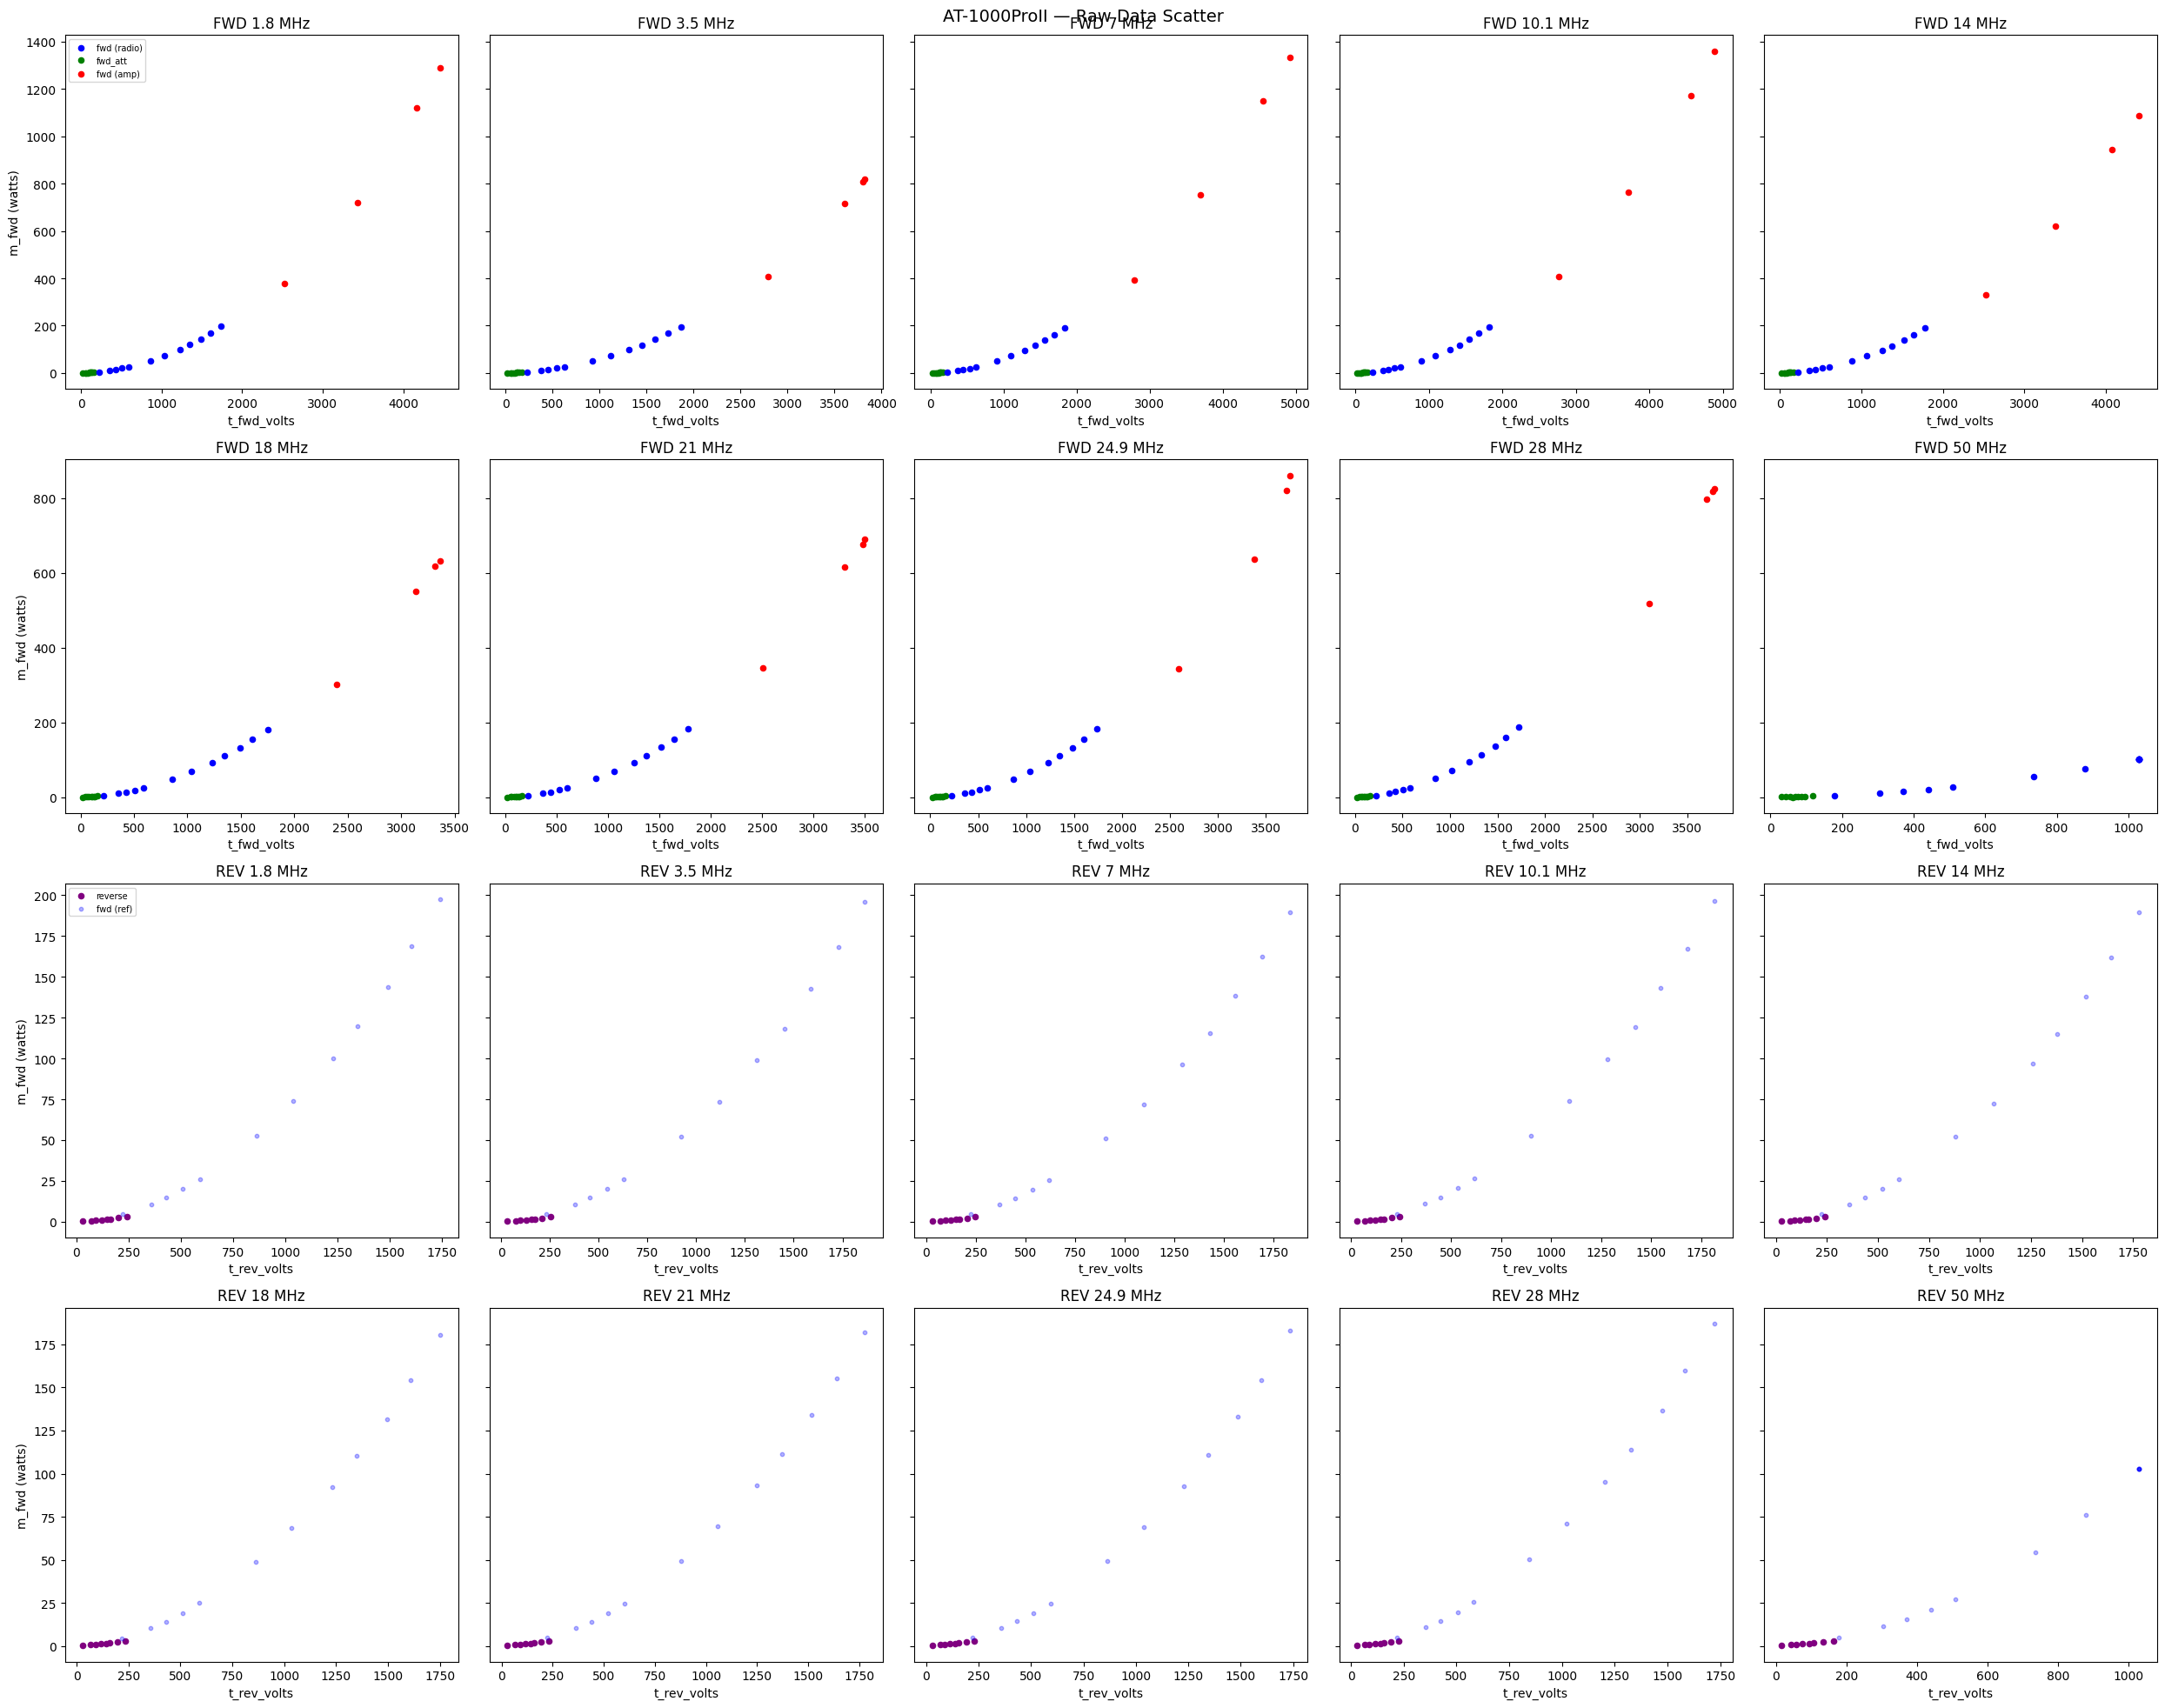

In [13]:
fig, axes = plt.subplots(4, 5, figsize=(25, 20), sharey='row')
fig.suptitle('AT-1000ProII — Raw Data Scatter', fontsize=14)

for i, (band, label) in enumerate(zip(BANDS, BAND_LABELS)):
    row, col = divmod(i, 5)
    # Forward row
    ax = axes[row][col]
    # radio-only forward (mid power)
    pts = [p for p in fwd_data if p['freq'] == band]
    if pts:
        ax.scatter([p['t_fwd_volts'] for p in pts], [p['m_fwd'] for p in pts],
                   c='blue', s=20, label='fwd (radio)', zorder=3)
    # attenuated forward (low power)
    pts = [p for p in fwd_att_data if p['freq'] == band]
    if pts:
        ax.scatter([p['t_fwd_volts'] for p in pts], [p['m_fwd'] for p in pts],
                   c='green', s=20, label='fwd_att', zorder=2)
    # amp forward (high power)
    pts = [p for p in amp_data if p['freq'] == band and p.get('t_fwd_volts')]
    if pts:
        ax.scatter([p['t_fwd_volts'] for p in pts], [p['m_fwd'] for p in pts],
                   c='red', s=20, label='fwd (amp)', zorder=4)
    ax.set_title(f'FWD {label}')
    ax.set_xlabel('t_fwd_volts')
    if col == 0:
        ax.set_ylabel('m_fwd (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

    # Reverse row
    ax = axes[row + 2][col]
    pts = [p for p in rev_data if p['freq'] == band]
    if pts:
        ax.scatter([p['t_rev_volts'] for p in pts], [p['m_fwd'] for p in pts],
                   c='purple', s=20, label='reverse')
        # also show fwd for reference
        fwd_pts = [p for p in fwd_data if p['freq'] == band]
        if fwd_pts:
            ax.scatter([p['t_fwd_volts'] for p in fwd_pts], [p['m_fwd'] for p in fwd_pts],
                       c='blue', s=10, alpha=0.3, label='fwd (ref)')
    ax.set_title(f'REV {label}')
    ax.set_xlabel('t_rev_volts')
    if col == 0:
        ax.set_ylabel('m_fwd (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/raw_scatter.png', dpi=150)
plt.show()

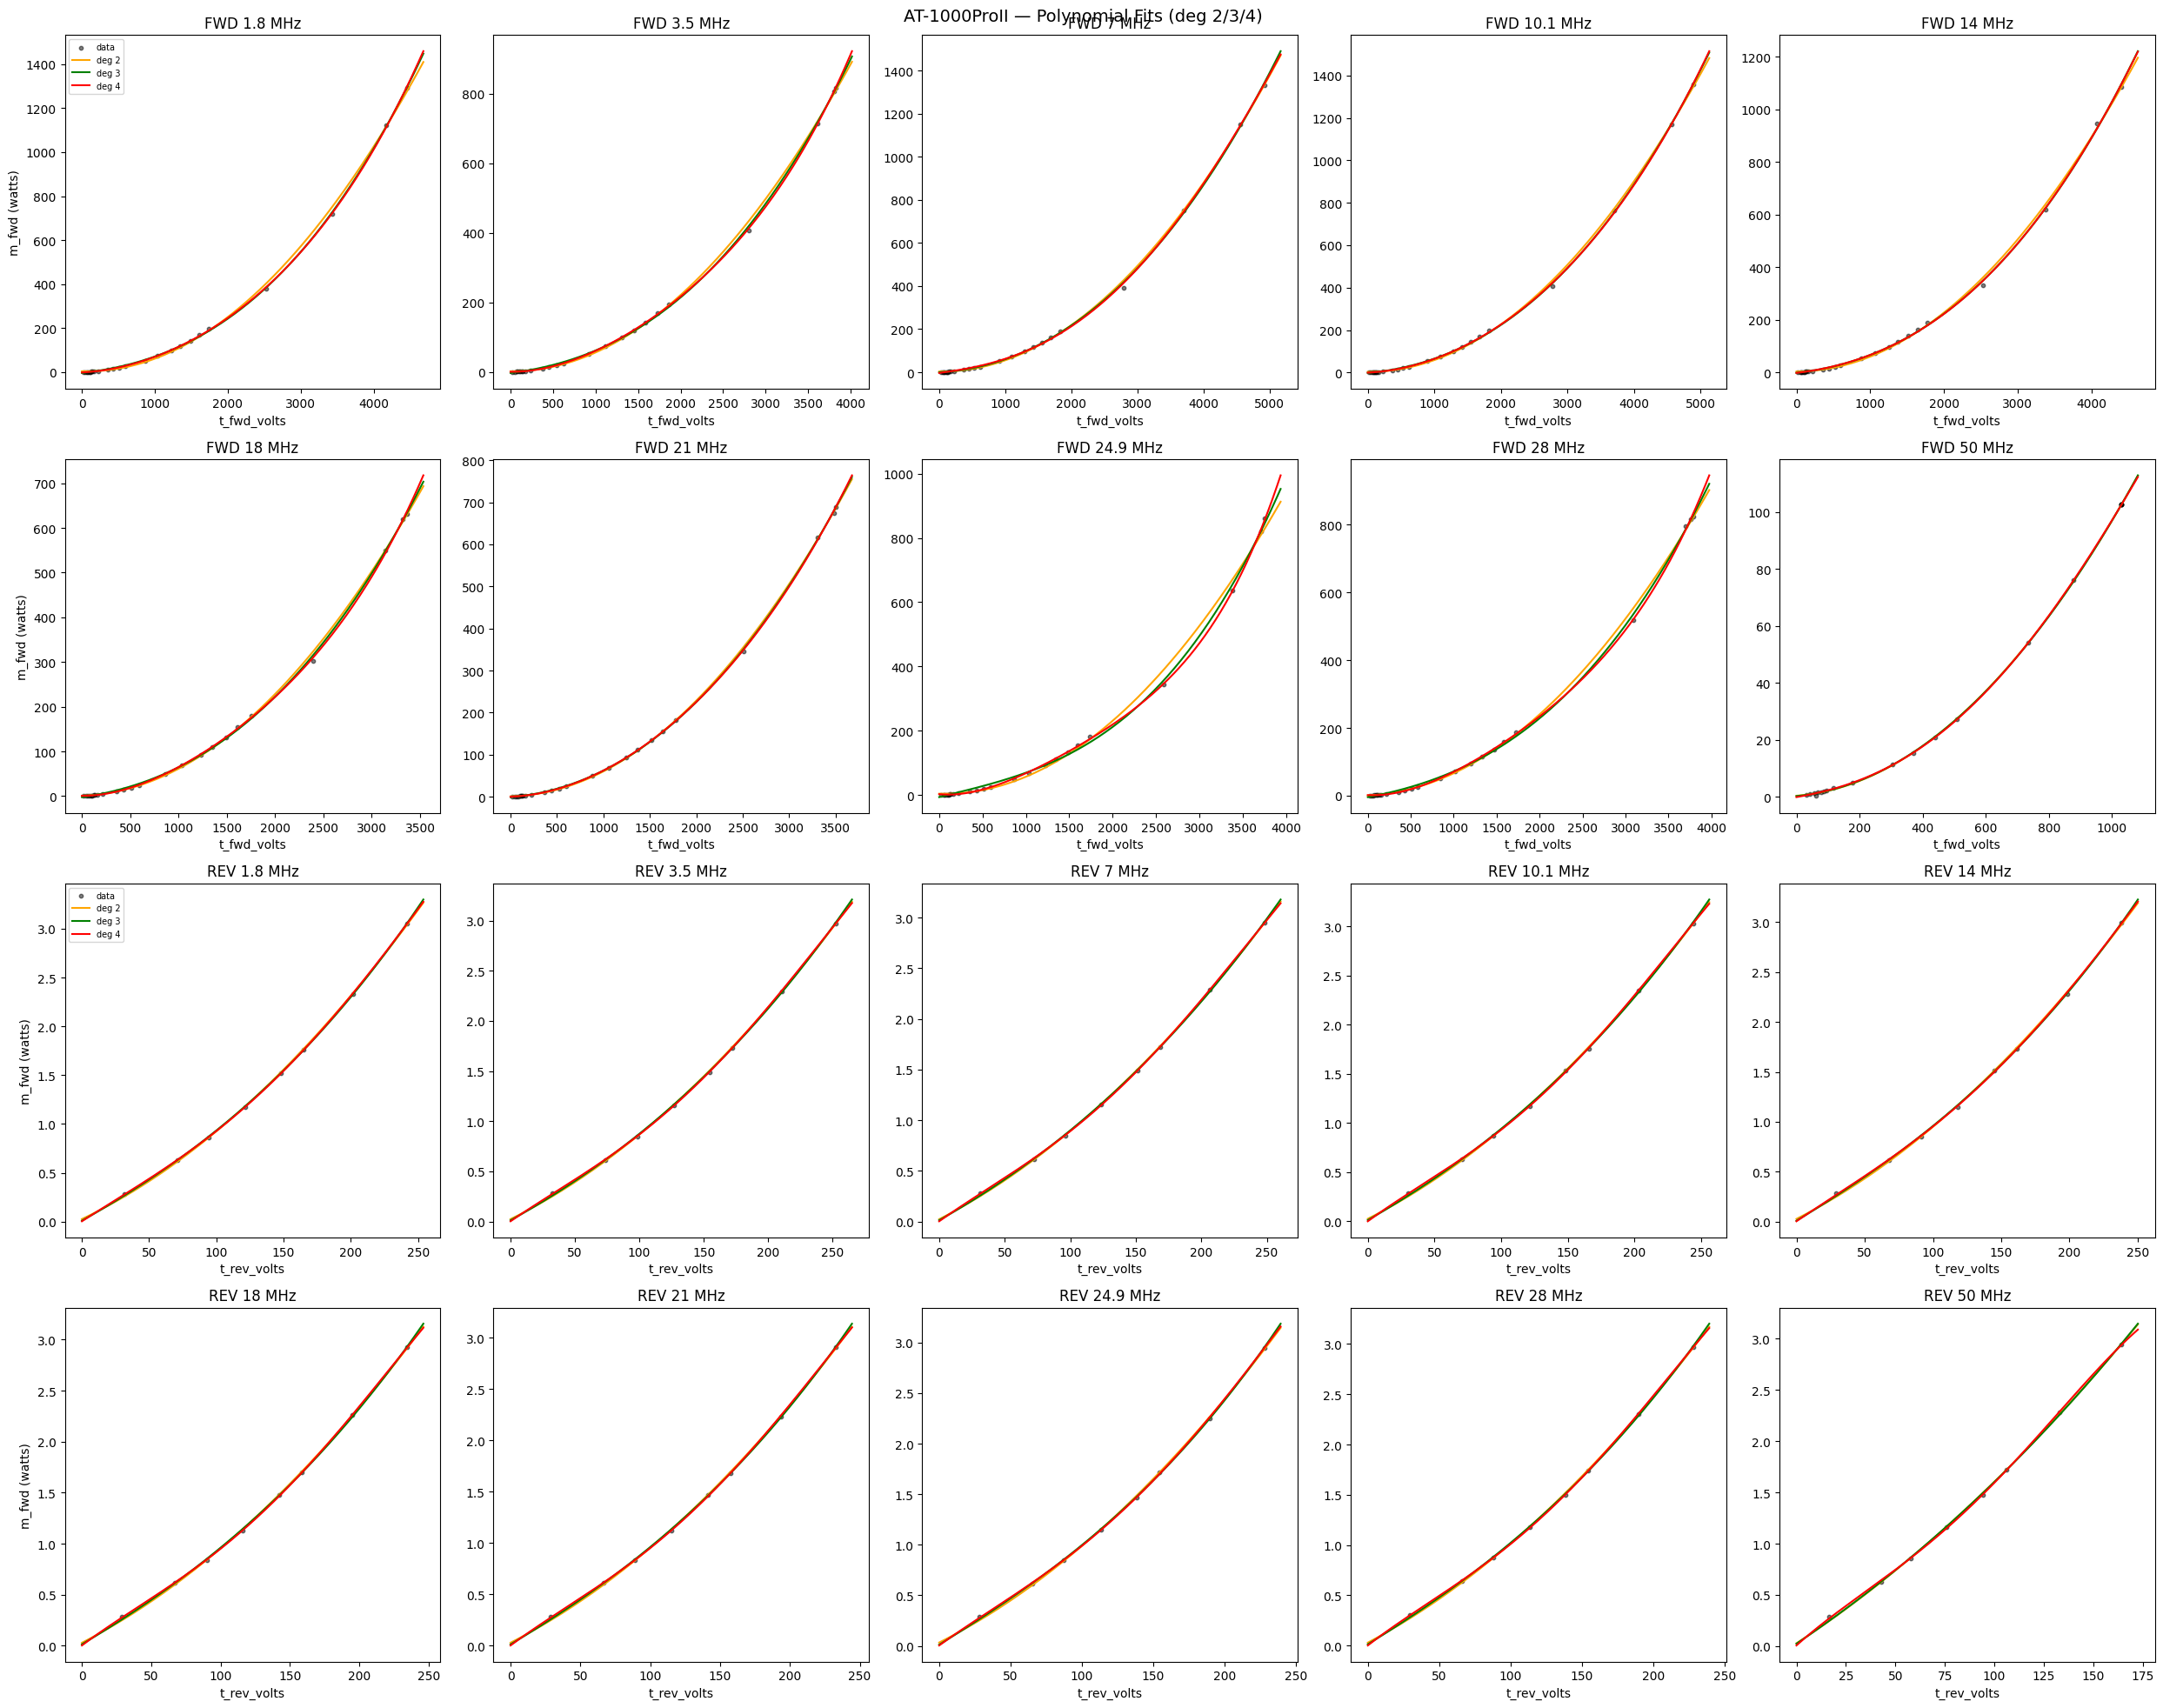

In [14]:
def fit_poly(data, x_key, y_key, degree=2, origin=True):
    """Fit polynomial to data points, optionally prepending origin."""
    x = [0, *([p[x_key] for p in data])] if origin else [p[x_key] for p in data]
    y = [0, *([p[y_key] for p in data])] if origin else [p[y_key] for p in data]
    return np.poly1d(np.polyfit(x, y, degree))


fig, axes = plt.subplots(4, 5, figsize=(25, 20))
fig.suptitle('AT-1000ProII — Polynomial Fits (deg 2/3/4)', fontsize=14)

colors = {'deg 2': 'orange', 'deg 3': 'green', 'deg 4': 'red'}

for i, (band, label) in enumerate(zip(BANDS, BAND_LABELS)):
    row, col = divmod(i, 5)

    # Forward
    ax = axes[row][col]
    pts = [p for p in all_fwd if p['freq'] == band]
    if not pts:
        ax.set_title(f'FWD {label} (no data)')
        continue

    x_raw = [p['t_fwd_volts'] for p in pts]
    y_raw = [p['m_fwd'] for p in pts]
    ax.scatter(x_raw, y_raw, c='black', s=10, alpha=0.5, label='data')

    x_fit = np.linspace(0, max(x_raw) * 1.05, 200)
    for deg, color in colors.items():
        poly = fit_poly(pts, 't_fwd_volts', 'm_fwd', degree=int(deg.split()[1]), origin=True)
        ax.plot(x_fit, poly(x_fit), color=color, linewidth=1.5, label=deg)

    ax.set_title(f'FWD {label}')
    ax.set_xlabel('t_fwd_volts')
    if col == 0:
        ax.set_ylabel('m_fwd (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

    # Reverse
    ax = axes[row + 2][col]
    pts = [p for p in rev_data if p['freq'] == band]
    if not pts:
        ax.set_title(f'REV {label} (no data)')
        continue

    x_raw = [p['t_rev_volts'] for p in pts]
    y_raw = [p['m_fwd'] for p in pts]
    ax.scatter(x_raw, y_raw, c='black', s=10, alpha=0.5, label='data')

    x_fit = np.linspace(0, max(x_raw) * 1.05, 200)
    for deg, color in colors.items():
        poly = fit_poly(pts, 't_rev_volts', 'm_fwd', degree=int(deg.split()[1]), origin=True)
        ax.plot(x_fit, poly(x_fit), color=color, linewidth=1.5, label=deg)

    ax.set_title(f'REV {label}')
    ax.set_xlabel('t_rev_volts')
    if col == 0:
        ax.set_ylabel('m_fwd (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/poly_overlay.png', dpi=150)
plt.show()

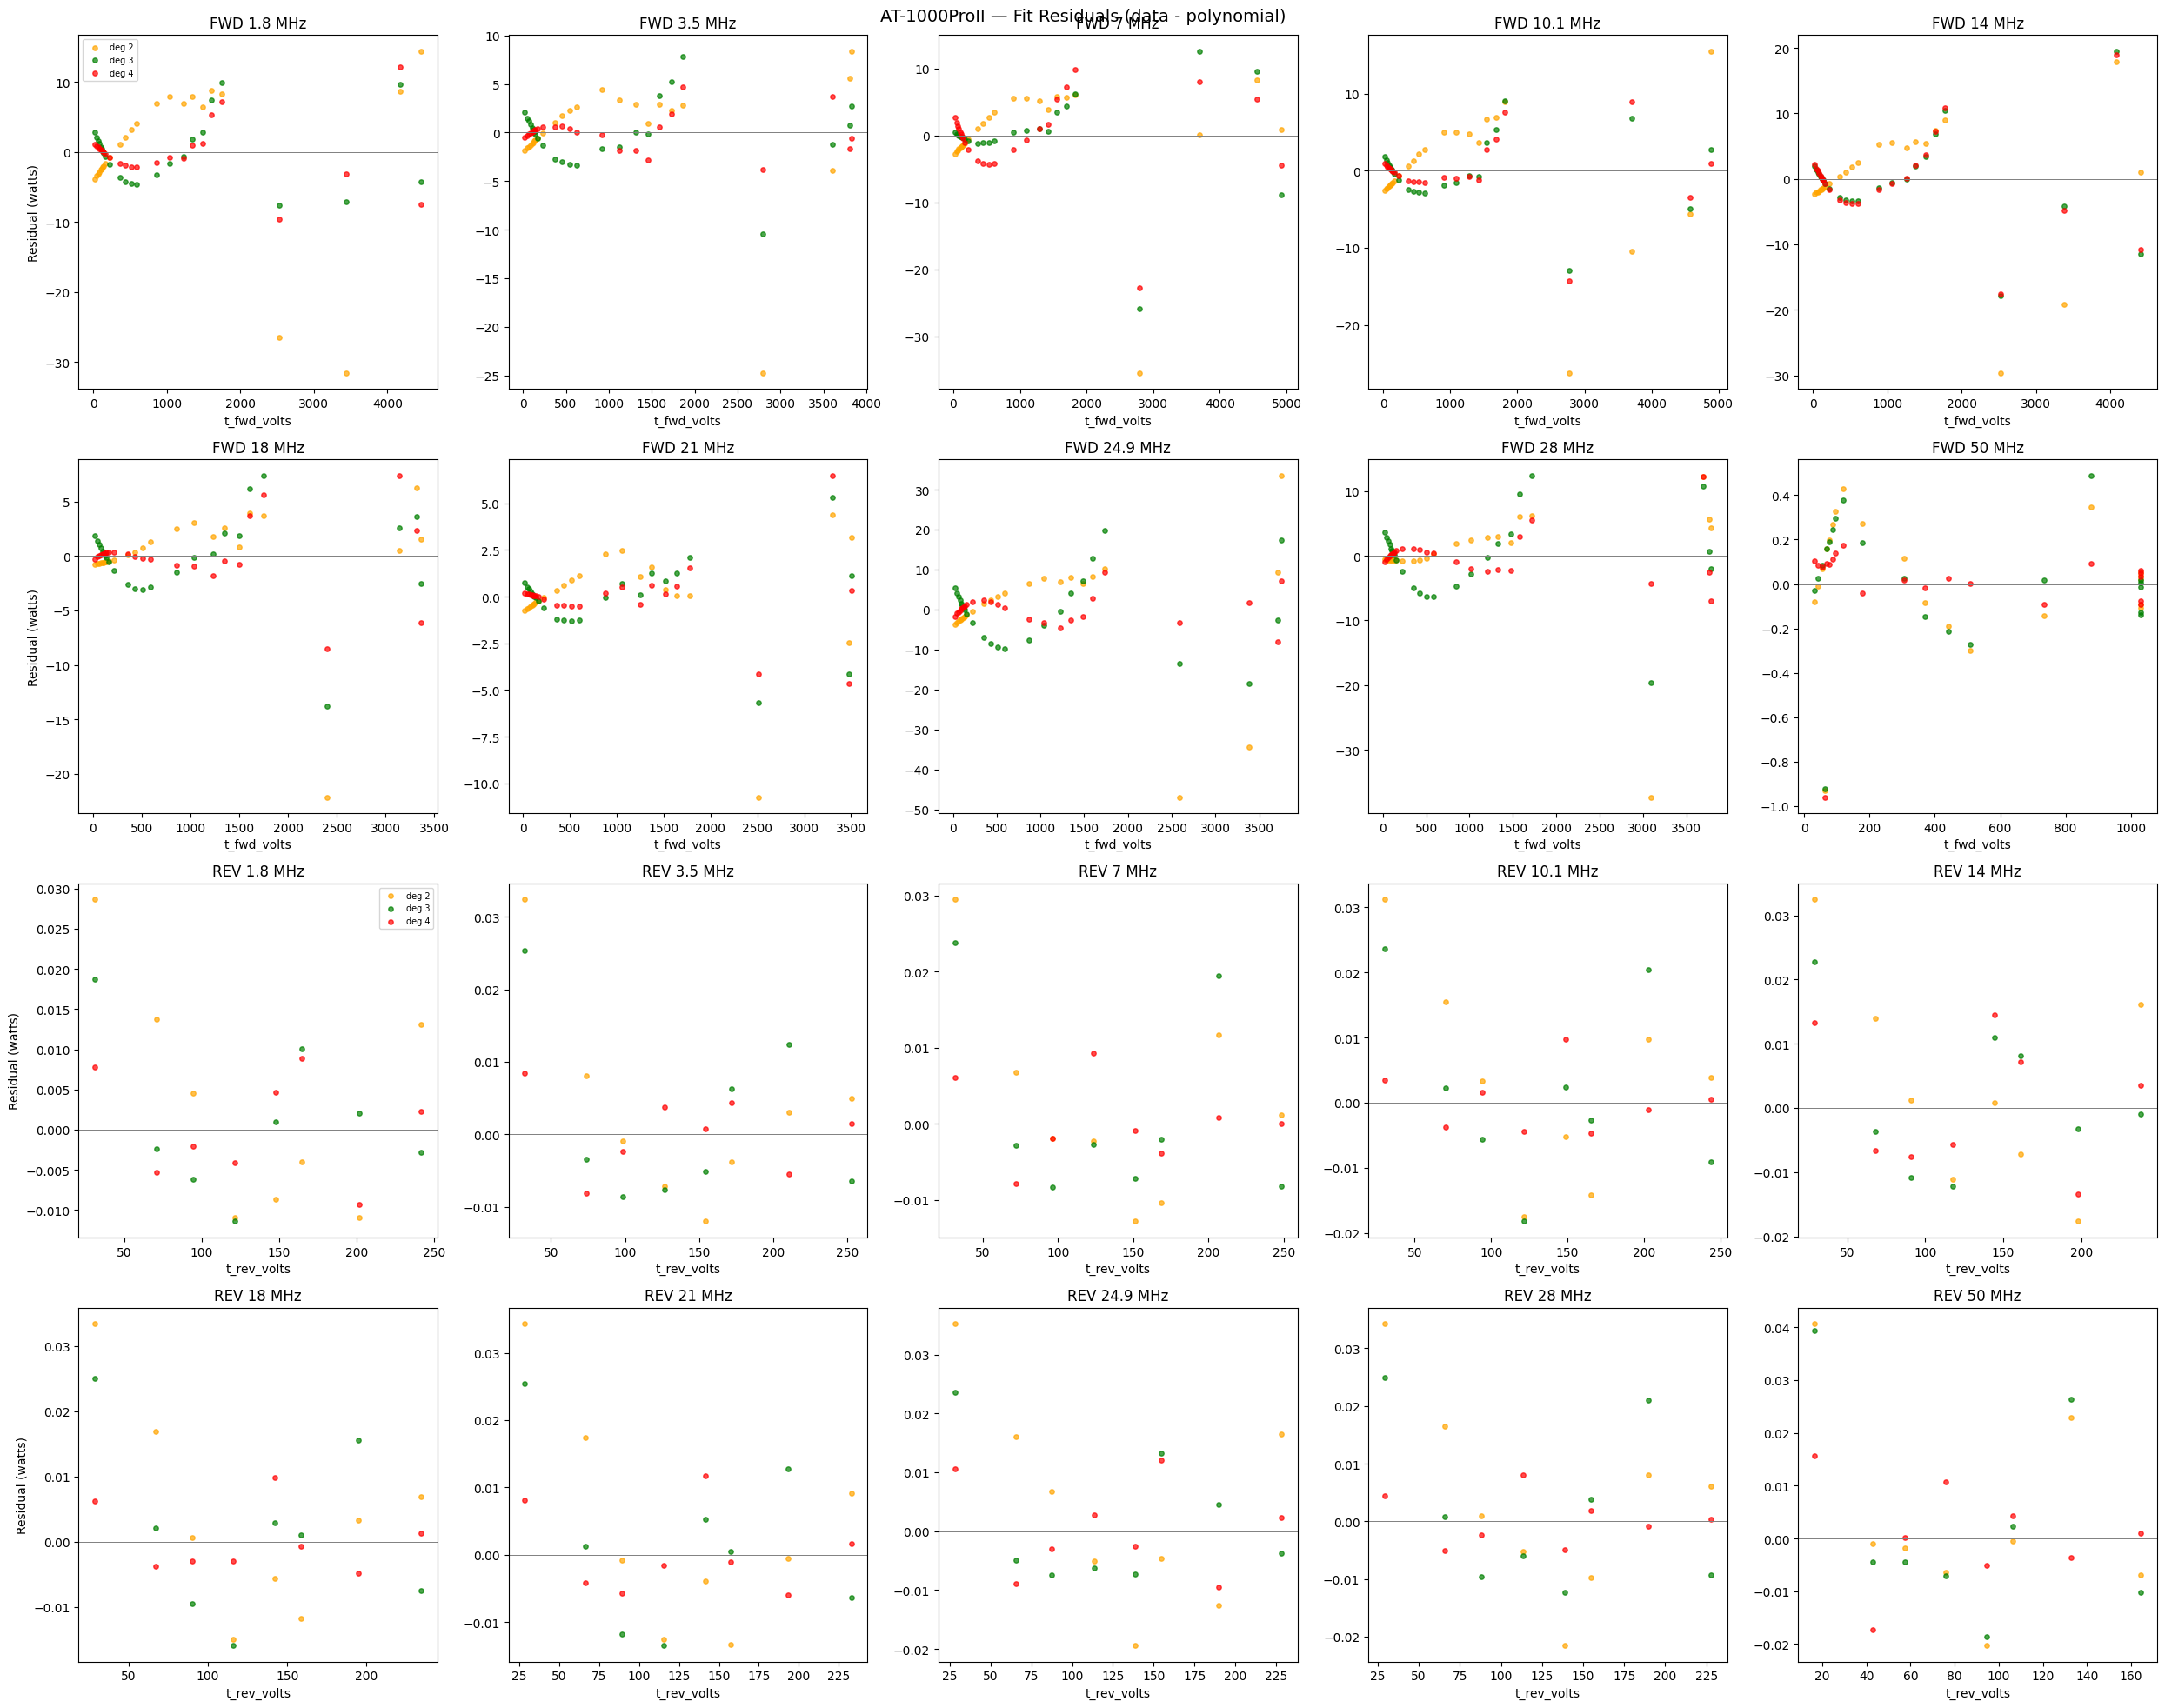

In [15]:
fig, axes = plt.subplots(4, 5, figsize=(25, 20))
fig.suptitle('AT-1000ProII — Fit Residuals (data - polynomial)', fontsize=14)

for i, (band, label) in enumerate(zip(BANDS, BAND_LABELS)):
    row, col = divmod(i, 5)
    ax = axes[row][col]
    pts = [p for p in all_fwd if p['freq'] == band]
    if not pts:
        continue

    x_all = [p['t_fwd_volts'] for p in pts]
    y_all = [p['m_fwd'] for p in pts]

    for deg, color in [('2', 'orange'), ('3', 'green'), ('4', 'red')]:
        poly = fit_poly(pts, 't_fwd_volts', 'm_fwd', degree=int(deg), origin=True)
        residuals = [y - poly(x) for x, y in zip(x_all, y_all)]
        ax.scatter(x_all, residuals, s=15, alpha=0.7, color=color, label=f'deg {deg}')
        ax.axhline(y=0, color='gray', linewidth=0.5)

    ax.set_title(f'FWD {label}')
    ax.set_xlabel('t_fwd_volts')
    if col == 0:
        ax.set_ylabel('Residual (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

# Reverse residuals
for i, (band, label) in enumerate(zip(BANDS, BAND_LABELS)):
    row, col = divmod(i, 5)
    ax = axes[row + 2][col]
    pts = [p for p in rev_data if p['freq'] == band]
    if not pts:
        continue

    x_all = [p['t_rev_volts'] for p in pts]
    y_all = [p['m_fwd'] for p in pts]

    for deg, color in [('2', 'orange'), ('3', 'green'), ('4', 'red')]:
        poly = fit_poly(pts, 't_rev_volts', 'm_fwd', degree=int(deg), origin=True)
        residuals = [y - poly(x) for x, y in zip(x_all, y_all)]
        ax.scatter(x_all, residuals, s=15, alpha=0.7, color=color, label=f'deg {deg}')
        ax.axhline(y=0, color='gray', linewidth=0.5)

    ax.set_title(f'REV {label}')
    ax.set_xlabel('t_rev_volts')
    if col == 0:
        ax.set_ylabel('Residual (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/residuals.png', dpi=150)
plt.show()

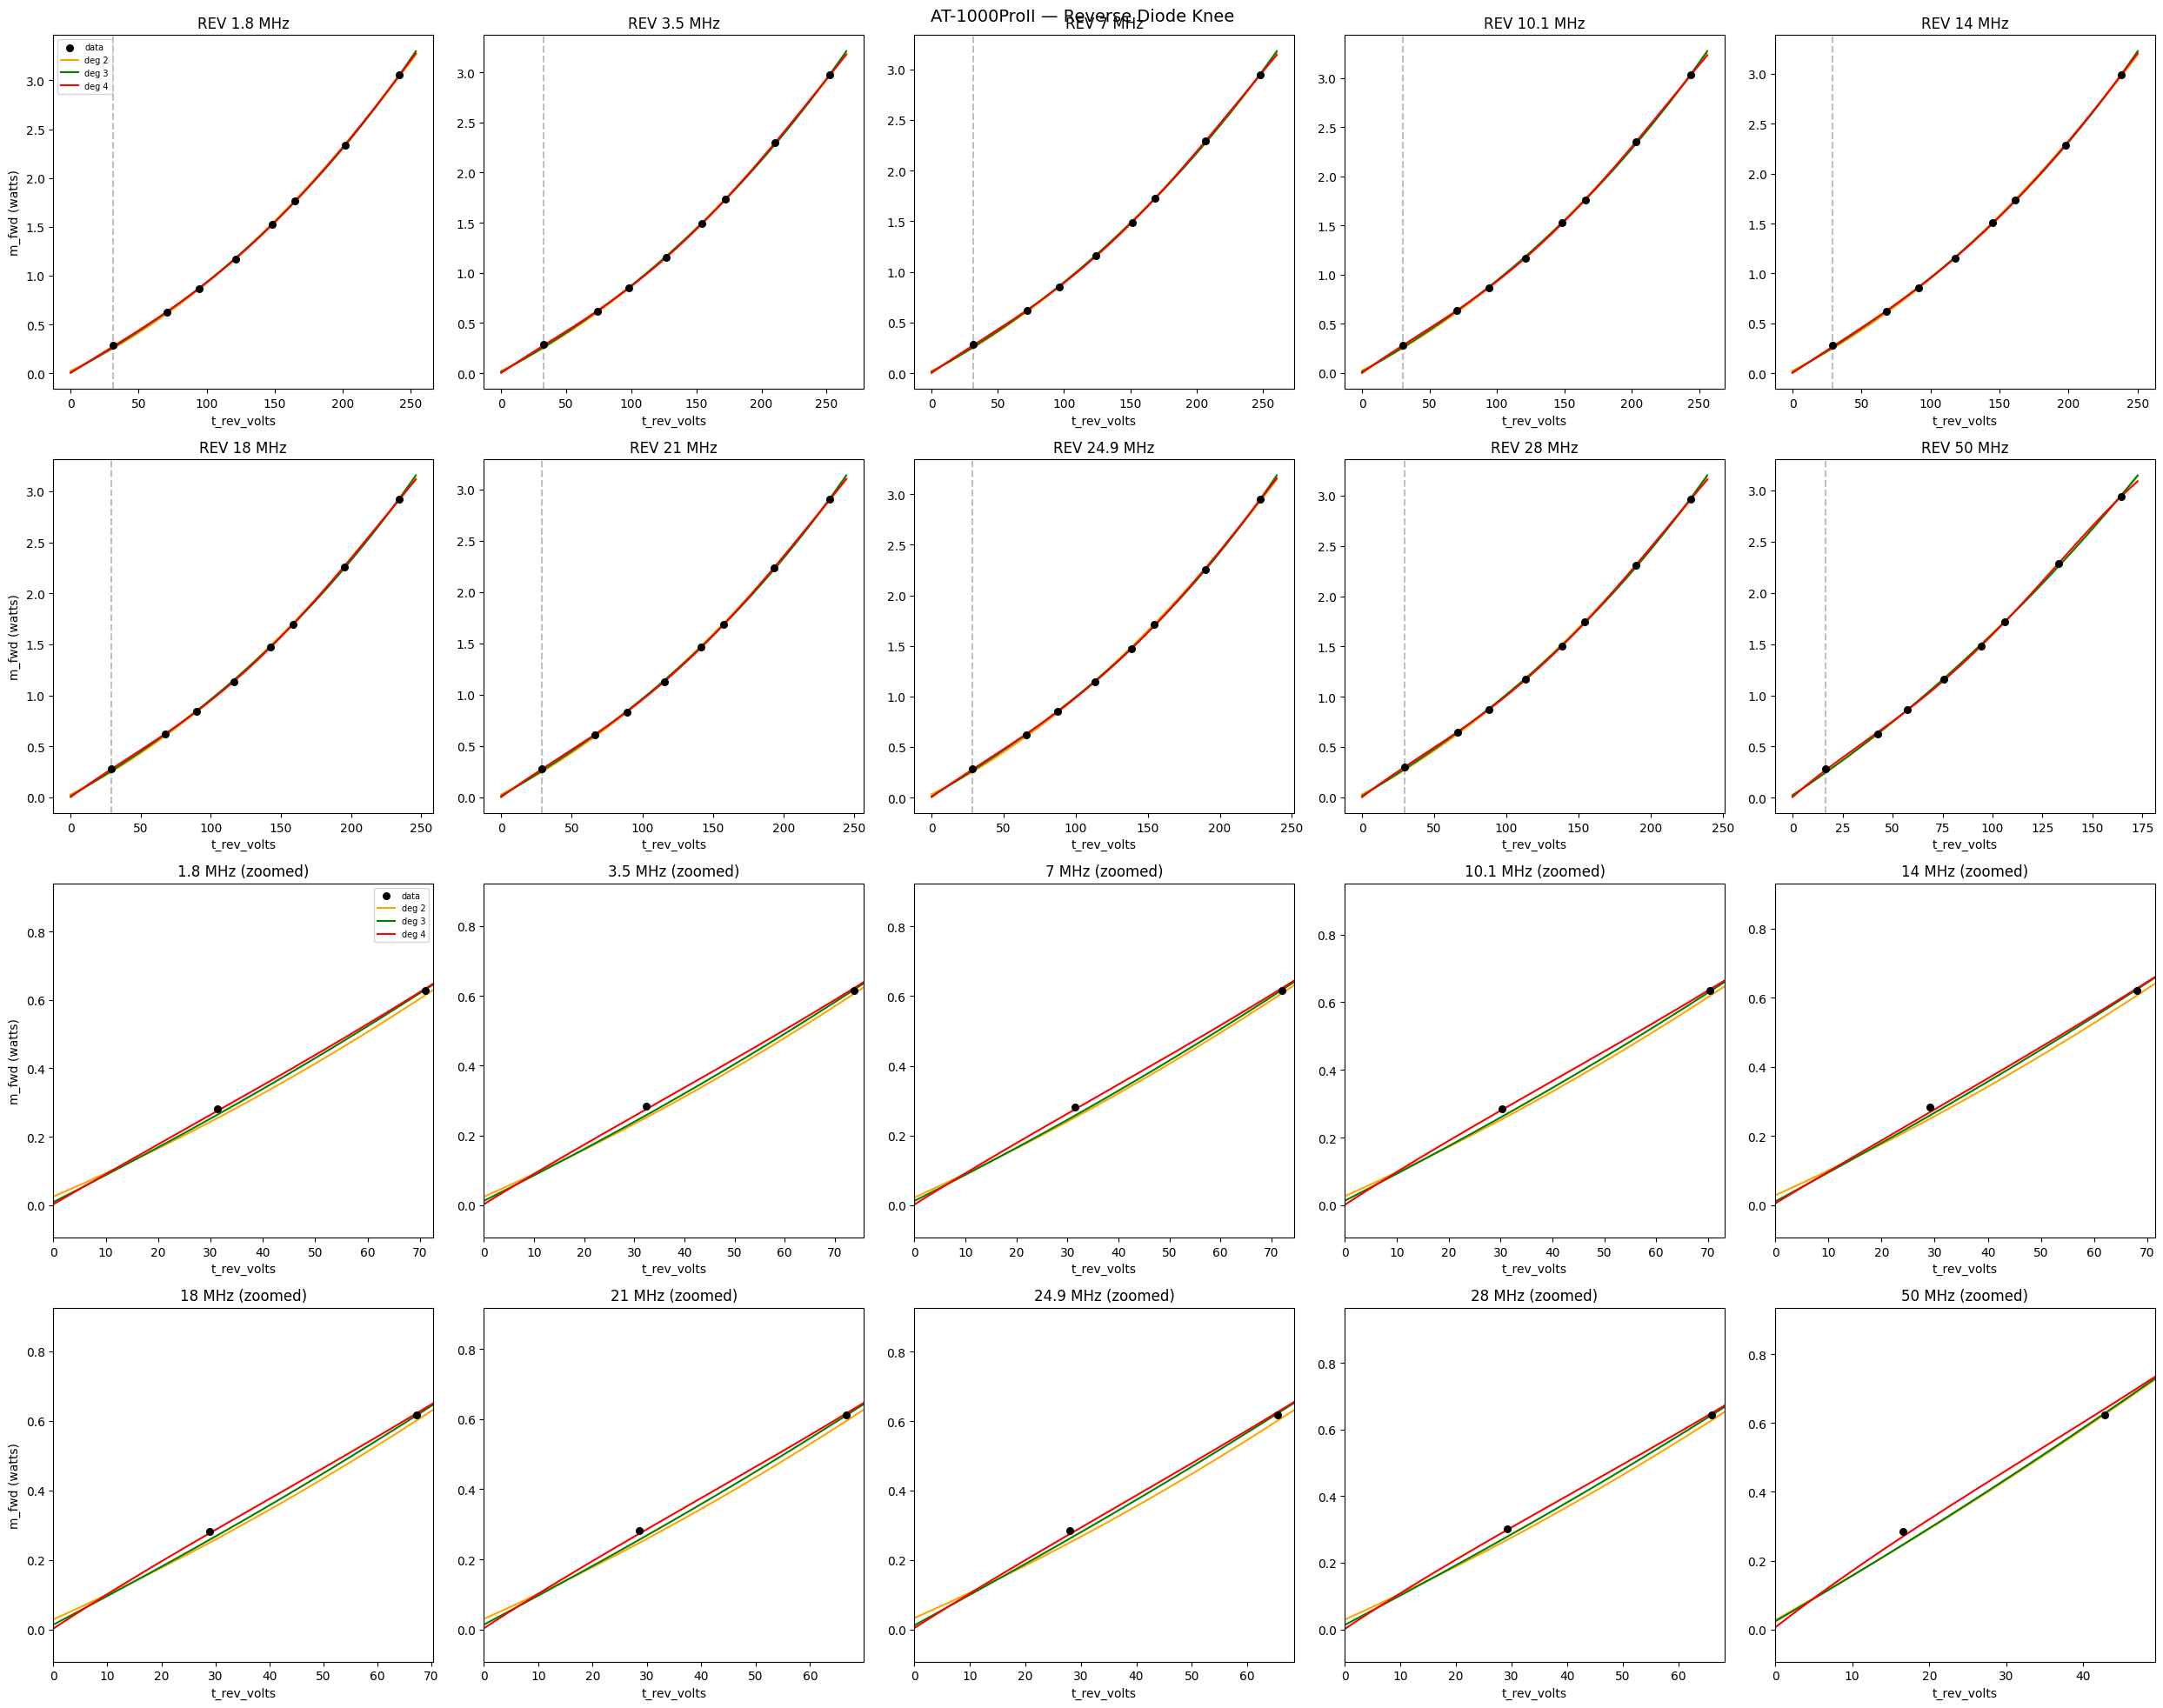

In [16]:
fig, axes = plt.subplots(4, 5, figsize=(25, 20))
fig.suptitle('AT-1000ProII — Reverse Diode Knee', fontsize=14)

# Full-range reverse plots
for i, (band, label) in enumerate(zip(BANDS, BAND_LABELS)):
    row, col = divmod(i, 5)
    ax = axes[row][col]
    pts = [p for p in rev_data if p['freq'] == band]
    if not pts:
        ax.set_title(f'{label} (no data)')
        continue

    pts_sorted = sorted(pts, key=lambda p: p['t_rev_volts'])
    x_raw = [p['t_rev_volts'] for p in pts_sorted]
    y_raw = [p['m_fwd'] for p in pts_sorted]

    ax.scatter(x_raw, y_raw, c='black', s=30, zorder=5, label='data')

    x_fit = np.linspace(0, max(x_raw) * 1.05, 300)
    for deg, color in [(2, 'orange'), (3, 'green'), (4, 'red')]:
        poly = fit_poly(pts, 't_rev_volts', 'm_fwd', degree=deg, origin=True)
        ax.plot(x_fit, poly(x_fit), color=color, linewidth=1.5, label=f'deg {deg}')

    nonzero = [p for p in pts_sorted if p['t_rev_volts'] > 5]
    if nonzero:
        ax.axvline(x=nonzero[0]['t_rev_volts'], color='gray', linestyle='--', alpha=0.5)

    ax.set_title(f'REV {label}')
    ax.set_xlabel('t_rev_volts')
    if col == 0:
        ax.set_ylabel('m_fwd (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

# Zoomed into knee region (bottom 30% of voltage range)
for i, (band, label) in enumerate(zip(BANDS, BAND_LABELS)):
    row, col = divmod(i, 5)
    ax = axes[row + 2][col]
    pts = [p for p in rev_data if p['freq'] == band]
    if not pts:
        continue

    pts_sorted = sorted(pts, key=lambda p: p['t_rev_volts'])
    x_raw = [p['t_rev_volts'] for p in pts_sorted]
    y_raw = [p['m_fwd'] for p in pts_sorted]
    max_x = max(x_raw)

    ax.scatter(x_raw, y_raw, c='black', s=30, zorder=5, label='data')

    x_fit = np.linspace(0, max_x * 0.3, 200)
    for deg, color in [(2, 'orange'), (3, 'green'), (4, 'red')]:
        poly = fit_poly(pts, 't_rev_volts', 'm_fwd', degree=deg, origin=True)
        ax.plot(x_fit, poly(x_fit), color=color, linewidth=1.5, label=f'deg {deg}')

    ax.set_xlim(0, max_x * 0.3)
    max_y_zoom = max((p['m_fwd'] for p in pts if p['t_rev_volts'] <= max_x * 0.3), default=1) * 1.5
    ax.set_ylim(-max_y_zoom * 0.1, max_y_zoom if max_y_zoom > 0 else 1)

    ax.set_title(f'{label} (zoomed)')
    ax.set_xlabel('t_rev_volts')
    if col == 0:
        ax.set_ylabel('m_fwd (watts)')
    if col == 0 and row == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/diode_knee.png', dpi=150)
plt.show()

In [17]:
# Generate C header tables for each degree, so we can compare the actual coefficients

def make_header(polys, name, bands):
    lines = [f'polynomial_t {name}[NUM_OF_BANDS] = {{']
    for band in sorted(bands):
        p = polys[band]
        coeffs = ', '.join(str(c) for c in p.coeffs)
        lines.append(f'    {{{coeffs}}}, // {band}')
    lines.append('};')
    return '\n'.join(lines)

for DEGREE in [2, 3, 4]:
    print(f'\n===== DEGREE {DEGREE} =====')
    fwd_polys = {}
    rev_polys = {}
    for band in BANDS:
        fwd_pts = [p for p in all_fwd if p['freq'] == band]
        rev_pts = [p for p in rev_data if p['freq'] == band]
        if fwd_pts:
            fwd_polys[band] = fit_poly(fwd_pts, 't_fwd_volts', 'm_fwd', degree=DEGREE, origin=True)
        if rev_pts:
            rev_polys[band] = fit_poly(rev_pts, 't_rev_volts', 'm_fwd', degree=DEGREE, origin=True)

    print(f'\n--- Forward (degree {DEGREE}) ---')
    print(make_header(fwd_polys, 'forwardCalibrationTable', BANDS))
    print(f'\n--- Reverse (degree {DEGREE}) ---')
    print(make_header(rev_polys, 'reverseCalibrationTable', BANDS))


===== DEGREE 2 =====

--- Forward (degree 2) ---
polynomial_t forwardCalibrationTable[NUM_OF_BANDS] = {
    {6.595034527125757e-05, -0.008770916953073887, 4.267063971719355}, // 01800000
    {5.555152526620236e-05, -0.0013622980332828852, 2.132780125140809}, // 03500000
    {5.566171036411798e-05, -0.003400349501686412, 3.0658875268466965}, // 07000000
    {5.635439351853247e-05, -0.00076351887367324, 2.8881012324034474}, // 10100000
    {5.534024805642005e-05, 0.0013674790922201905, 2.5214517338580915}, // 14000000
    {5.3534915836196356e-05, 0.006715982511277534, 0.9121178821086339}, // 18068000
    {5.445281370107398e-05, 0.0049156383999510505, 0.8943918104784132}, // 21000000
    {6.0570621859999385e-05, -0.007799442953429614, 4.051479951156664}, // 24890000
    {5.4278874661625806e-05, 0.011089625078803358, 0.6467664795259671}, // 28000000
    {8.830426939235808e-05, 0.008326818318796737, 0.35919623662550515}, // 50000000
};

--- Reverse (degree 2) ---
polynomial_t reverseCalibr